Dataset loaded successfully!
Shape: (30000, 13)
Columns: ['Job Title', 'Industry', 'Job Status', 'AI Impact Level', 'Median Salary (USD)', 'Required Education', 'Experience Required (Years)', 'Job Openings (2024)', 'Projected Openings (2030)', 'Remote Work Ratio (%)', 'Automation Risk (%)', 'Location', 'Gender Diversity (%)']

🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
STARTING COMPREHENSIVE EDA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


BASIC DATASET INFORMATION

Dataset Shape: (30000, 13)
Total Rows: 30000
Total Columns: 13

--------------------------------------------------------------------------------
Data Types:
--------------------------------------------------------------------------------
Job Title                       object
Industry                        object
Job Status                      object
AI Impact Level                 object
Median Salary (USD)            float64
Required Education              object
Experience Required (Years)      int64
Job Openings (2024)   

FileNotFoundError: [Errno 2] No such file or directory: '../visualizations/01_automation_risk_distribution.png'

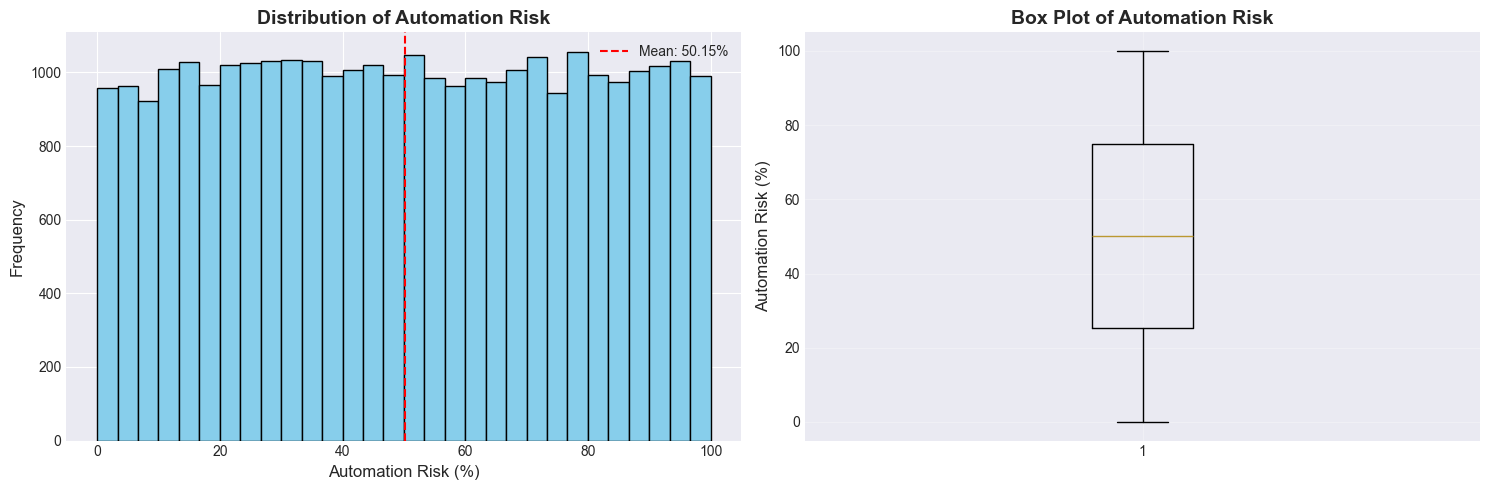

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class JobAutomationEDA:
    
    def __init__(self, data_path):
        """Initialize with dataset path"""
        self.df = pd.read_excel(data_path)
        self.output_dir = '../visualizations'
        print(f"Dataset loaded successfully!")
        print(f"Shape: {self.df.shape}")
        print(f"Columns: {list(self.df.columns)}")
        
    def basic_info(self):
        """Display basic dataset information"""
        print("\n" + "="*80)
        print("BASIC DATASET INFORMATION")
        print("="*80)
        
        print(f"\nDataset Shape: {self.df.shape}")
        print(f"Total Rows: {self.df.shape[0]}")
        print(f"Total Columns: {self.df.shape[1]}")
        
        print("\n" + "-"*80)
        print("Data Types:")
        print("-"*80)
        print(self.df.dtypes)
        
        print("\n" + "-"*80)
        print("Missing Values:")
        print("-"*80)
        missing = self.df.isnull().sum()
        if missing.sum() == 0:
            print("✓ No missing values found!")
        else:
            print(missing[missing > 0])
        
        print("\n" + "-"*80)
        print("Duplicate Rows:")
        print("-"*80)
        duplicates = self.df.duplicated().sum()
        print(f"Number of duplicate rows: {duplicates}")
        
        print("\n" + "-"*80)
        print("Statistical Summary:")
        print("-"*80)
        print(self.df.describe())
        
        return self.df.info()
    
    def univariate_analysis(self):
        """Analyze individual variables"""
        print("\n" + "="*80)
        print("UNIVARIATE ANALYSIS")
        print("="*80)
        
        # Numerical columns
        numerical_cols = ['Median Salary (USD)', 'Experience Required (Years)', 
                         'Job Openings (2024)', 'Projected Openings (2030)',
                         'Remote Work Ratio (%)', 'Automation Risk (%)', 
                         'Gender Diversity (%)']
        
        # Categorical columns
        categorical_cols = ['Industry', 'Job Status', 'AI Impact Level', 
                           'Required Education', 'Location']
        
        # 1. Distribution of Target Variable (Automation Risk)
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Histogram
        axes[0].hist(self.df['Automation Risk (%)'], bins=30, color='skyblue', edgecolor='black')
        axes[0].set_xlabel('Automation Risk (%)', fontsize=12)
        axes[0].set_ylabel('Frequency', fontsize=12)
        axes[0].set_title('Distribution of Automation Risk', fontsize=14, fontweight='bold')
        axes[0].axvline(self.df['Automation Risk (%)'].mean(), color='red', 
                       linestyle='--', label=f'Mean: {self.df["Automation Risk (%)"].mean():.2f}%')
        axes[0].legend()
        
        # Box plot
        axes[1].boxplot(self.df['Automation Risk (%)'], vert=True)
        axes[1].set_ylabel('Automation Risk (%)', fontsize=12)
        axes[1].set_title('Box Plot of Automation Risk', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/01_automation_risk_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 2. Distribution of all numerical variables
        fig, axes = plt.subplots(3, 3, figsize=(18, 15))
        axes = axes.ravel()
        
        for idx, col in enumerate(numerical_cols):
            axes[idx].hist(self.df[col], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
            axes[idx].set_xlabel(col, fontsize=10)
            axes[idx].set_ylabel('Frequency', fontsize=10)
            axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
            axes[idx].axvline(self.df[col].mean(), color='blue', linestyle='--', 
                            label=f'Mean: {self.df[col].mean():.2f}')
            axes[idx].legend(fontsize=8)
        
        # Remove extra subplots
        for idx in range(len(numerical_cols), len(axes)):
            fig.delaxes(axes[idx])
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/02_numerical_distributions.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 3. Categorical variables analysis
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.ravel()
        
        for idx, col in enumerate(categorical_cols):
            value_counts = self.df[col].value_counts()
            axes[idx].bar(range(len(value_counts)), value_counts.values, 
                         color=plt.cm.Set3(np.linspace(0, 1, len(value_counts))))
            axes[idx].set_xticks(range(len(value_counts)))
            axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)
            axes[idx].set_ylabel('Count', fontsize=10)
            axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
            
            # Add count labels on bars
            for i, v in enumerate(value_counts.values):
                axes[idx].text(i, v + 100, str(v), ha='center', va='bottom', fontsize=8)
        
        # Remove extra subplot
        fig.delaxes(axes[5])
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/03_categorical_distributions.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✓ Univariate analysis completed!")
        print(f"✓ Visualizations saved in '{self.output_dir}' directory")
    
    def bivariate_analysis(self):
        """Analyze relationships between variables"""
        print("\n" + "="*80)
        print("BIVARIATE ANALYSIS")
        print("="*80)
        
        # 1. Automation Risk vs Industry
        fig, ax = plt.subplots(figsize=(14, 6))
        industry_risk = self.df.groupby('Industry')['Automation Risk (%)'].mean().sort_values(ascending=False)
        bars = ax.bar(range(len(industry_risk)), industry_risk.values, 
                     color=plt.cm.RdYlGn_r(industry_risk.values / 100))
        ax.set_xticks(range(len(industry_risk)))
        ax.set_xticklabels(industry_risk.index, rotation=45, ha='right', fontsize=11)
        ax.set_ylabel('Average Automation Risk (%)', fontsize=12)
        ax.set_title('Average Automation Risk by Industry', fontsize=14, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for i, v in enumerate(industry_risk.values):
            ax.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/04_risk_by_industry.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 2. Automation Risk vs Education Level
        fig, ax = plt.subplots(figsize=(12, 6))
        edu_risk = self.df.groupby('Required Education')['Automation Risk (%)'].mean().sort_values(ascending=False)
        bars = ax.barh(range(len(edu_risk)), edu_risk.values,
                      color=plt.cm.Spectral(edu_risk.values / 100))
        ax.set_yticks(range(len(edu_risk)))
        ax.set_yticklabels(edu_risk.index, fontsize=11)
        ax.set_xlabel('Average Automation Risk (%)', fontsize=12)
        ax.set_title('Average Automation Risk by Education Level', fontsize=14, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        
        # Add value labels
        for i, v in enumerate(edu_risk.values):
            ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/05_risk_by_education.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 3. Automation Risk vs Job Status
        fig, ax = plt.subplots(figsize=(10, 6))
        status_risk = self.df.groupby('Job Status')['Automation Risk (%)'].mean()
        colors = ['#2ecc71' if status == 'Increasing' else '#e74c3c' for status in status_risk.index]
        bars = ax.bar(status_risk.index, status_risk.values, color=colors, edgecolor='black', linewidth=2)
        ax.set_ylabel('Average Automation Risk (%)', fontsize=12)
        ax.set_title('Average Automation Risk by Job Status', fontsize=14, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        for i, v in enumerate(status_risk.values):
            ax.text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/06_risk_by_job_status.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 4. Salary vs Automation Risk
        fig, ax = plt.subplots(figsize=(12, 6))
        scatter = ax.scatter(self.df['Median Salary (USD)'], self.df['Automation Risk (%)'],
                           c=self.df['Automation Risk (%)'], cmap='RdYlGn_r', 
                           alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
        ax.set_xlabel('Median Salary (USD)', fontsize=12)
        ax.set_ylabel('Automation Risk (%)', fontsize=12)
        ax.set_title('Relationship between Salary and Automation Risk', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Automation Risk (%)', fontsize=11)
        
        # Add correlation
        correlation = self.df['Median Salary (USD)'].corr(self.df['Automation Risk (%)'])
        ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
               transform=ax.transAxes, fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/07_salary_vs_risk.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 5. Experience vs Automation Risk
        fig, ax = plt.subplots(figsize=(12, 6))
        scatter = ax.scatter(self.df['Experience Required (Years)'], self.df['Automation Risk (%)'],
                           c=self.df['Automation Risk (%)'], cmap='coolwarm', 
                           alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
        ax.set_xlabel('Experience Required (Years)', fontsize=12)
        ax.set_ylabel('Automation Risk (%)', fontsize=12)
        ax.set_title('Relationship between Experience and Automation Risk', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Automation Risk (%)', fontsize=11)
        
        correlation = self.df['Experience Required (Years)'].corr(self.df['Automation Risk (%)'])
        ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
               transform=ax.transAxes, fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/08_experience_vs_risk.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 6. Remote Work vs Automation Risk
        fig, ax = plt.subplots(figsize=(12, 6))
        scatter = ax.scatter(self.df['Remote Work Ratio (%)'], self.df['Automation Risk (%)'],
                           c=self.df['Automation Risk (%)'], cmap='viridis', 
                           alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
        ax.set_xlabel('Remote Work Ratio (%)', fontsize=12)
        ax.set_ylabel('Automation Risk (%)', fontsize=12)
        ax.set_title('Relationship between Remote Work and Automation Risk', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Automation Risk (%)', fontsize=11)
        
        correlation = self.df['Remote Work Ratio (%)'].corr(self.df['Automation Risk (%)'])
        ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
               transform=ax.transAxes, fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/09_remote_work_vs_risk.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✓ Bivariate analysis completed!")
    
    def multivariate_analysis(self):
        """Analyze multiple variables together"""
        print("\n" + "="*80)
        print("MULTIVARIATE ANALYSIS")
        print("="*80)
        
        # 1. Correlation Matrix
        numerical_cols = ['Median Salary (USD)', 'Experience Required (Years)', 
                         'Job Openings (2024)', 'Projected Openings (2030)',
                         'Remote Work Ratio (%)', 'Automation Risk (%)', 
                         'Gender Diversity (%)']
        
        fig, ax = plt.subplots(figsize=(12, 10))
        corr_matrix = self.df[numerical_cols].corr()
        
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                   ax=ax, vmin=-1, vmax=1)
        ax.set_title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/10_correlation_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print top correlations with Automation Risk
        print("\nTop Correlations with Automation Risk:")
        print("-" * 60)
        correlations = corr_matrix['Automation Risk (%)'].sort_values(ascending=False)
        for feature, corr in correlations.items():
            if feature != 'Automation Risk (%)':
                print(f"{feature:35s}: {corr:6.3f}")
        
        # 2. Pairplot for key features
        print("\nGenerating pairplot (this may take a moment)...")
        key_features = ['Automation Risk (%)', 'Median Salary (USD)', 
                       'Experience Required (Years)', 'Remote Work Ratio (%)']
        
        # Sample data for faster plotting
        sample_df = self.df[key_features].sample(n=min(1000, len(self.df)), random_state=42)
        
        pairplot = sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.6},
                               corner=True)
        pairplot.fig.suptitle('Pairplot of Key Features (Sample of 1000 records)', 
                             y=1.02, fontsize=14, fontweight='bold')
        plt.savefig(f'{self.output_dir}/11_pairplot.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 3. Job Growth Analysis
        self.df['Job_Growth'] = ((self.df['Projected Openings (2030)'] - 
                                 self.df['Job Openings (2024)']) / 
                                self.df['Job Openings (2024)'] * 100)
        
        fig, ax = plt.subplots(figsize=(14, 6))
        scatter = ax.scatter(self.df['Job_Growth'], self.df['Automation Risk (%)'],
                           c=self.df['Automation Risk (%)'], cmap='RdYlGn_r',
                           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
        ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% Risk Threshold')
        ax.axvline(x=0, color='blue', linestyle='--', linewidth=2, label='No Growth/Decline Line')
        ax.set_xlabel('Job Growth Rate (%) [2024-2030]', fontsize=12)
        ax.set_ylabel('Automation Risk (%)', fontsize=12)
        ax.set_title('Job Growth vs Automation Risk', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Automation Risk (%)', fontsize=11)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/12_job_growth_vs_risk.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 4. Industry-wise detailed analysis
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Average metrics by industry
        industry_metrics = self.df.groupby('Industry').agg({
            'Automation Risk (%)': 'mean',
            'Median Salary (USD)': 'mean',
            'Remote Work Ratio (%)': 'mean',
            'Job_Growth': 'mean'
        }).round(2)
        
        # Plot 1: Automation Risk by Industry
        industry_metrics['Automation Risk (%)'].sort_values().plot(kind='barh', ax=axes[0, 0],
                                                                   color='coral')
        axes[0, 0].set_xlabel('Average Automation Risk (%)', fontsize=11)
        axes[0, 0].set_title('Average Automation Risk by Industry', fontsize=12, fontweight='bold')
        axes[0, 0].grid(axis='x', alpha=0.3)
        
        # Plot 2: Salary by Industry
        industry_metrics['Median Salary (USD)'].sort_values().plot(kind='barh', ax=axes[0, 1],
                                                                    color='lightblue')
        axes[0, 1].set_xlabel('Average Salary (USD)', fontsize=11)
        axes[0, 1].set_title('Average Salary by Industry', fontsize=12, fontweight='bold')
        axes[0, 1].grid(axis='x', alpha=0.3)
        
        # Plot 3: Remote Work Ratio by Industry
        industry_metrics['Remote Work Ratio (%)'].sort_values().plot(kind='barh', ax=axes[1, 0],
                                                                     color='lightgreen')
        axes[1, 0].set_xlabel('Average Remote Work Ratio (%)', fontsize=11)
        axes[1, 0].set_title('Average Remote Work Ratio by Industry', fontsize=12, fontweight='bold')
        axes[1, 0].grid(axis='x', alpha=0.3)
        
        # Plot 4: Job Growth by Industry
        industry_metrics['Job_Growth'].sort_values().plot(kind='barh', ax=axes[1, 1],
                                                          color='plum')
        axes[1, 1].set_xlabel('Average Job Growth (%)', fontsize=11)
        axes[1, 1].set_title('Average Job Growth by Industry (2024-2030)', 
                            fontsize=12, fontweight='bold')
        axes[1, 1].grid(axis='x', alpha=0.3)
        axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/13_industry_comprehensive.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✓ Multivariate analysis completed!")
    
    def generate_insights(self):
        """Generate key insights from the data"""
        print("\n" + "="*80)
        print("KEY INSIGHTS & FINDINGS")
        print("="*80)
        
        insights = []
        
        # 1. Overall automation risk
        avg_risk = self.df['Automation Risk (%)'].mean()
        insights.append(f"1. Average automation risk across all jobs: {avg_risk:.2f}%")
        
        # 2. Industry with highest risk
        industry_risk = self.df.groupby('Industry')['Automation Risk (%)'].mean()
        highest_risk_industry = industry_risk.idxmax()
        insights.append(f"2. Industry with highest automation risk: {highest_risk_industry} "
                       f"({industry_risk.max():.2f}%)")
        
        # 3. Education impact
        edu_risk = self.df.groupby('Required Education')['Automation Risk (%)'].mean().sort_values()
        insights.append(f"3. Lowest risk education level: {edu_risk.index[0]} ({edu_risk.values[0]:.2f}%)")
        insights.append(f"4. Highest risk education level: {edu_risk.index[-1]} ({edu_risk.values[-1]:.2f}%)")
        
        # 4. Job status impact
        status_risk = self.df.groupby('Job Status')['Automation Risk (%)'].mean()
        insights.append(f"5. Increasing jobs average risk: {status_risk['Increasing']:.2f}%")
        insights.append(f"6. Decreasing jobs average risk: {status_risk['Decreasing']:.2f}%")
        
        # 5. Salary correlation
        salary_corr = self.df['Median Salary (USD)'].corr(self.df['Automation Risk (%)'])
        insights.append(f"7. Correlation between salary and automation risk: {salary_corr:.3f}")
        
        # 6. High risk jobs
        high_risk_jobs = self.df[self.df['Automation Risk (%)'] > 80].shape[0]
        high_risk_pct = (high_risk_jobs / len(self.df)) * 100
        insights.append(f"8. Jobs with >80% automation risk: {high_risk_jobs} ({high_risk_pct:.2f}%)")
        
        # 7. Low risk jobs
        low_risk_jobs = self.df[self.df['Automation Risk (%)'] < 30].shape[0]
        low_risk_pct = (low_risk_jobs / len(self.df)) * 100
        insights.append(f"9. Jobs with <30% automation risk: {low_risk_jobs} ({low_risk_pct:.2f}%)")
        
        # 8. Remote work impact
        remote_corr = self.df['Remote Work Ratio (%)'].corr(self.df['Automation Risk (%)'])
        insights.append(f"10. Correlation between remote work and automation risk: {remote_corr:.3f}")
        
        for insight in insights:
            print(f"   {insight}")
        
        # Save insights to file
        with open(f'{self.output_dir}/insights.txt', 'w') as f:
            f.write("KEY INSIGHTS FROM EDA\n")
            f.write("="*80 + "\n\n")
            for insight in insights:
                f.write(insight + "\n")
        
        print(f"\n✓ Insights saved to '{self.output_dir}/insights.txt'")
        
        return insights
    
    def run_complete_eda(self):
        """Run complete EDA pipeline"""
        print("\n" + "🔍 "*20)
        print("STARTING COMPREHENSIVE EDA")
        print("🔍 "*20 + "\n")
        
        self.basic_info()
        self.univariate_analysis()
        self.bivariate_analysis()
        self.multivariate_analysis()
        insights = self.generate_insights()
        
        print("\n" + "✅ "*20)
        print("EDA COMPLETED SUCCESSFULLY!")
        print("✅ "*20)
        print(f"\n📊 All visualizations saved in '{self.output_dir}' directory")
        print(f"📝 Total insights generated: {len(insights)}")
        
        return self.df

# Main execution
if __name__ == "__main__":
    # Initialize EDA
    eda = JobAutomationEDA('ai_job_trends_dataset.xlsx')
    
    # Run complete analysis
    df = eda.run_complete_eda()
    
    print("\n" + "="*80)
    print("You can now proceed to Feature Engineering!")
    print("="*80)